In [1]:
# ==========================================
# Cell 1 : Import Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Activation,
    Masking,
    Bidirectional,
    LSTM
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 50)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("Pandas Version     :", pd.__version__)
print("=" * 50)

TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2
Pandas Version     : 2.2.2


In [2]:
# ==========================================
# Cell 2 : Load MSCAD Dataset
# ==========================================

DATA_PATH = "MSCAD.csv"   # Change if required

# Load dataset
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("MSCAD Dataset Loaded Successfully")
print("=" * 60)

print(f"Dataset Shape : {df.shape}")

# Display first five rows
display(df.head())

# -----------------------------
# Basic Information
# -----------------------------
print("\nDataset Info")
print("-" * 40)
print(df.info())

# -----------------------------
# Detect Label Column
# -----------------------------
LABEL_COL = "Label"

assert LABEL_COL in df.columns, "Label column not found!"

FEATURE_COLS = [c for c in df.columns if c != LABEL_COL]

print(f"\nNumber of Features : {len(FEATURE_COLS)}")
print(f"Label Column       : {LABEL_COL}")

print("\nFirst 10 Feature Columns")
print(FEATURE_COLS[:10])

MSCAD Dataset Loaded Successfully
Dataset Shape : (128799, 67)


,'Flow Duration','Tot Fwd Pkts','Tot Bwd Pkts','TotLen Fwd Pkts','TotLen Bwd Pkts','Fwd Pkt Len Max','Fwd Pkt Len Min','Fwd Pkt Len Mean','Fwd Pkt Len Std','Bwd Pkt Len Max',...,'Fwd Act Data Pkts','Active Mean','Active Std','Active Max','Active Min','Idle Mean','Idle Std','Idle Max','Idle Min',Label
0,1518,2,5,110,377,110,0,55.0,77.7817,377,...,1,0,0,0,0,0,0,0,0,Brute_Force
1,5894,4,8,168,4498,168,0,42.0,84.0000,1460,...,1,0,0,0,0,0,0,0,0,Brute_Force
2,272,1,1,0,0,0,0,0.0,0.0000,0,...,0,0,0,0,0,0,0,0,0,Brute_Force
3,2611,4,8,322,4434,322,0,80.5,161.0000,1460,...,1,0,0,0,0,0,0,0,0,Brute_Force
4,294,1,1,0,0,0,0,0.0,0.0000,0,...,0,0,0,0,0,0,0,0,0,Brute_Force



Dataset Info
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128799 entries, 0 to 128798
Data columns (total 67 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   'Flow Duration'      128799 non-null  int64  
 1   'Tot Fwd Pkts'       128799 non-null  int64  
 2   'Tot Bwd Pkts'       128799 non-null  int64  
 3   'TotLen Fwd Pkts'    128799 non-null  int64  
 4   'TotLen Bwd Pkts'    128799 non-null  int64  
 5   'Fwd Pkt Len Max'    128799 non-null  int64  
 6   'Fwd Pkt Len Min'    128799 non-null  int64  
 7   'Fwd Pkt Len Mean'   128799 non-null  float64
 8   'Fwd Pkt Len Std'    128799 non-null  float64
 9   'Bwd Pkt Len Max'    128799 non-null  int64  
 10  'Bwd Pkt Len Min'    128799 non-null  int64  
 11  'Bwd Pkt Len Mean'   128799 non-null  float64
 12  'Bwd Pkt Len Std'    128799 non-null  float64
 13  'Flow Byts/s'        128799 non-null  float64
 14  'Flow Pkts/s'

DATASET OVERVIEW

Total Flows      : 128,799
Total Features   : 66
Classes          : 6

Label Distribution
----------------------------------------


,count
Label,
Brute_Force,88502
Normal,28502
Port_Scan,11081
HTTP_DDoS,641
ICMP_Flood,45
Web_Crwling,28


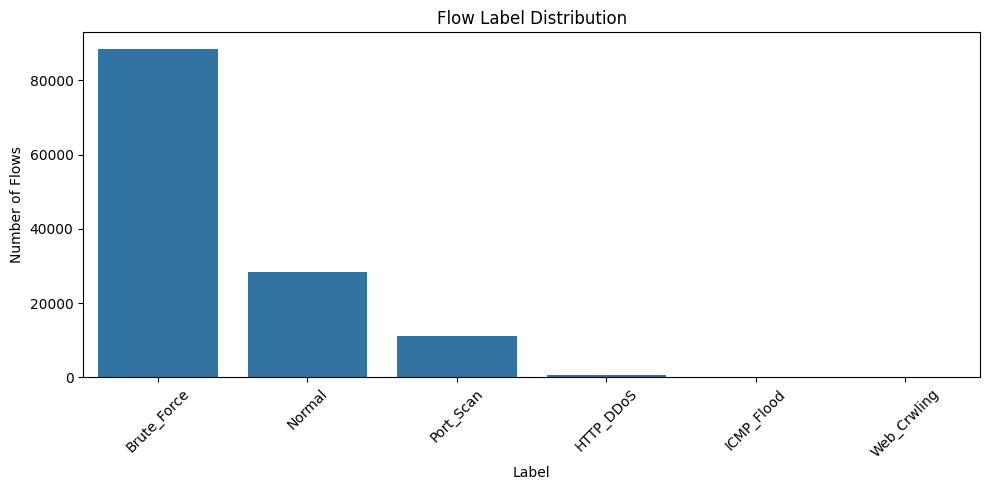


Missing Values
----------------------------------------
No Missing Values Found ✅

Infinite Values : 0
Duplicate Rows : 36764

Constant Features : 0

EDA Complete ✅


In [3]:
# ==========================================
# Cell 3 : Exploratory Data Analysis
# ==========================================

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"\nTotal Flows      : {len(df):,}")
print(f"Total Features   : {len(FEATURE_COLS)}")
print(f"Classes          : {df[LABEL_COL].nunique()}")

# -------------------------------------------------
# Label Distribution
# -------------------------------------------------

print("\nLabel Distribution")
print("-"*40)

label_counts = df[LABEL_COL].value_counts()

display(label_counts)

plt.figure(figsize=(10,5))
sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
)

plt.xticks(rotation=45)
plt.ylabel("Number of Flows")
plt.title("Flow Label Distribution")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Missing Values
# -------------------------------------------------

print("\nMissing Values")
print("-"*40)

missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing)==0:
    print("No Missing Values Found ✅")
else:
    display(missing.sort_values(ascending=False))

# -------------------------------------------------
# Infinite Values
# -------------------------------------------------

numeric_df = df[FEATURE_COLS].select_dtypes(include=np.number)

num_inf = np.isinf(numeric_df.values).sum()

print(f"\nInfinite Values : {num_inf}")

# -------------------------------------------------
# Duplicate Rows
# -------------------------------------------------

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

# -------------------------------------------------
# Constant Features
# -------------------------------------------------

constant_cols = [
    c for c in FEATURE_COLS
    if df[c].nunique()==1
]

print(f"\nConstant Features : {len(constant_cols)}")

if len(constant_cols)>0:
    print(constant_cols)

print("\nEDA Complete ✅")

In [4]:
# ==========================================
# Cell 4 : Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

# Features and labels
X = df[FEATURE_COLS].copy()
y = df[LABEL_COL].copy()

# -------------------------------------------------
# Stratified Split
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("="*60)
print("Train-Test Split Complete")
print("="*60)

print(f"Training Flows : {len(X_train):,}")
print(f"Testing Flows  : {len(X_test):,}")

print("\nTraining Distribution")
display(y_train.value_counts())

print("\nTesting Distribution")
display(y_test.value_counts())

Train-Test Split Complete
Training Flows : 103,039
Testing Flows  : 25,760

Training Distribution


,count
Label,
Brute_Force,70801
Normal,22802
Port_Scan,8865
HTTP_DDoS,513
ICMP_Flood,36
Web_Crwling,22



Testing Distribution


,count
Label,
Brute_Force,17701
Normal,5700
Port_Scan,2216
HTTP_DDoS,128
ICMP_Flood,9
Web_Crwling,6


In [5]:
# ==========================================
# Cell 5 : Scaling + Label Encoding
# ==========================================

from sklearn.preprocessing import StandardScaler, LabelEncoder

# -------------------------------------------------
# Label Encoding
# -------------------------------------------------

label_encoder = LabelEncoder()

# Fit ONLY on training labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Transform test labels
y_test_encoded = label_encoder.transform(y_test)

print("="*60)
print("Label Mapping")
print("="*60)

for idx, label in enumerate(label_encoder.classes_):
    print(f"{idx} --> {label}")

NUM_CLASSES = len(label_encoder.classes_)

# -------------------------------------------------
# Feature Scaling
# -------------------------------------------------

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*60)
print("Feature Scaling Complete")
print("="*60)

print(f"Training Shape : {X_train_scaled.shape}")
print(f"Testing Shape  : {X_test_scaled.shape}")

print(f"\nNumber of Classes : {NUM_CLASSES}")

Label Mapping
0 --> Brute_Force
1 --> HTTP_DDoS
2 --> ICMP_Flood
3 --> Normal
4 --> Port_Scan
5 --> Web_Crwling

Feature Scaling Complete
Training Shape : (103039, 66)
Testing Shape  : (25760, 66)

Number of Classes : 6


In [6]:
# ==========================================
# Cell 6 : Build Embedding Network
# ==========================================

from tensorflow.keras.layers import (
    Input,
    Dense,
    BatchNormalization,
    Dropout,
    Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# -------------------------------------------------
# Model Parameters
# -------------------------------------------------

INPUT_DIM = X_train_scaled.shape[1]   # 66 Features
EMBEDDING_DIM = 64

# -------------------------------------------------
# Build Network
# -------------------------------------------------

inputs = Input(shape=(INPUT_DIM,), name="Flow_Features")

# Block 1
x = Dense(256)(inputs)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.30)(x)

# Block 2
x = Dense(128)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.25)(x)

# Block 3
x = Dense(64)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)

# =========================================
# Embedding Layer
# =========================================

embedding = Dense(
    EMBEDDING_DIM,
    activation="linear",
    name="embedding_layer"
)(x)

# Classification Head
outputs = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(embedding)

# Create Model
embedding_classifier = Model(
    inputs=inputs,
    outputs=outputs,
    name="FlowEmbeddingNetwork"
)

# -------------------------------------------------
# Compile
# -------------------------------------------------

embedding_classifier.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------------------------
# Summary
# -------------------------------------------------

embedding_classifier.summary()

Model: "FlowEmbeddingNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Flow_Features (InputLayer)      │ (None, 66)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,646 (252.52 KB)

 Trainable params: 63,750 (249.02 KB)

 Non-trainable params: 896 (3.50 KB)

Class Weights
Brute_Force     : 0.243
HTTP_DDoS       : 33.476
ICMP_Flood      : 477.032
Normal          : 0.753
Port_Scan       : 1.937
Web_Crwling     : 780.598
Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8650 - loss: 1.0585 - val_accuracy: 0.9150 - val_loss: 0.3204 - learning_rate: 0.0010
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9027 - loss: 0.6078 - val_accuracy: 0.9235 - val_loss: 0.2002 - learning_rate: 0.0010
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9009 - loss: 0.5554 - val_accuracy: 0.8964 - val_loss: 0.3374 - learning_rate: 0.0010
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8972 - loss: 0.4891 - val_accuracy: 0.9256 - val_loss: 0.1740 - learning_rate: 0.0010
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9091 - loss: 0.4820 - val_accuracy: 0.9140 - val_loss: 0.2946 - learning_rate: 0.0010
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9088

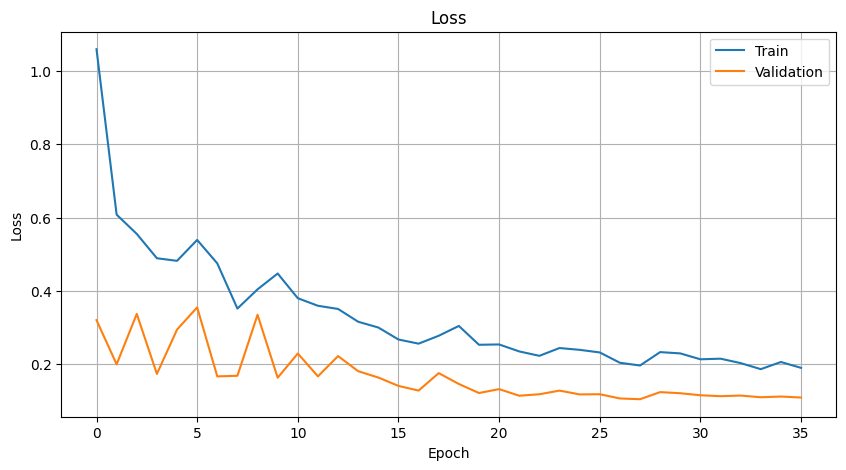

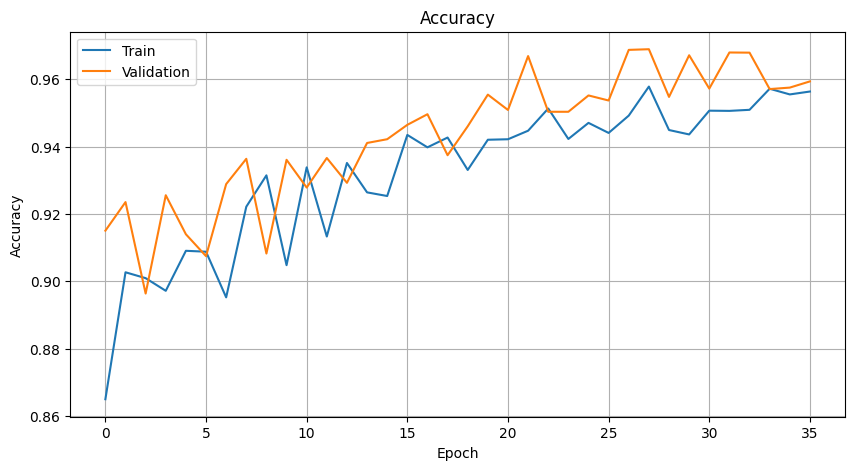

In [7]:
# ==========================================
# Cell 7 : Train Embedding Network
# ==========================================

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Compute Class Weights
# -------------------------------------------------

classes = np.unique(y_train_encoded)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

class_weights = {
    i: w for i, w in enumerate(weights)
}

print("="*60)
print("Class Weights")
print("="*60)

for i, w in class_weights.items():
    print(f"{label_encoder.classes_[i]:15s} : {w:.3f}")

# -------------------------------------------------
# Callbacks
# -------------------------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# -------------------------------------------------
# Train
# -------------------------------------------------

history = embedding_classifier.fit(
    X_train_scaled,
    y_train_encoded,

    validation_split=0.20,

    epochs=50,

    batch_size=512,

    class_weight=class_weights,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    shuffle=True,

    verbose=1
)

# -------------------------------------------------
# Plot Learning Curves
# -------------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# ==========================================
# Cell 8 : Extract Flow Embeddings
# ==========================================

from tensorflow.keras.models import Model
import tensorflow as tf

# -------------------------------------------------
# Create Embedding Model
# -------------------------------------------------

embedding_model = Model(
    inputs=embedding_classifier.input,
    outputs=embedding_classifier.get_layer("embedding_layer").output
)

print("Embedding Model Created Successfully!")

# -------------------------------------------------
# Generate Embeddings
# -------------------------------------------------

train_embeddings = embedding_model.predict(
    X_train_scaled,
    batch_size=1024,
    verbose=1
)

test_embeddings = embedding_model.predict(
    X_test_scaled,
    batch_size=1024,
    verbose=1
)

# -------------------------------------------------
# L2 Normalize Embeddings
# -------------------------------------------------

train_embeddings = tf.math.l2_normalize(
    train_embeddings,
    axis=1
).numpy()

test_embeddings = tf.math.l2_normalize(
    test_embeddings,
    axis=1
).numpy()

print("\nTraining Embeddings Shape :", train_embeddings.shape)
print("Testing Embeddings Shape  :", test_embeddings.shape)

print("\nEmbedding Dimension :", train_embeddings.shape[1])

# -------------------------------------------------
# Create DataFrames for Campaign Generator
# -------------------------------------------------

train_embedding_df = pd.DataFrame(train_embeddings)
train_embedding_df["Label"] = y_train.reset_index(drop=True)

test_embedding_df = pd.DataFrame(test_embeddings)
test_embedding_df["Label"] = y_test.reset_index(drop=True)

print("\nTraining Embedding DataFrame")
display(train_embedding_df.head())

Embedding Model Created Successfully!
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Training Embeddings Shape : (103039, 64)
Testing Embeddings Shape  : (25760, 64)

Embedding Dimension : 64

Training Embedding DataFrame


,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,Label
0,0.086697,0.133871,0.053990,0.096050,0.301029,-0.030821,0.048384,-0.091644,0.059332,-0.196618,...,0.095897,0.149465,0.039773,0.007382,0.161850,-0.008249,0.020967,0.117422,-0.061774,Brute_Force
1,0.090602,0.180042,0.020708,0.046383,0.124134,-0.081217,-0.036941,-0.057993,0.106061,-0.090153,...,0.139518,0.096698,0.059155,0.023543,0.070968,-0.033792,-0.187348,0.177641,0.031594,Brute_Force
2,0.037849,-0.087772,-0.050738,-0.154162,-0.206046,0.038166,0.142337,-0.014248,-0.185414,0.256509,...,-0.064635,-0.092834,-0.200968,0.080259,-0.253090,-0.136247,0.031538,-0.009590,-0.107368,Normal
3,0.090476,0.179270,0.019354,0.046184,0.124437,-0.079984,-0.036889,-0.057751,0.104714,-0.090867,...,0.138997,0.096340,0.059810,0.021774,0.070665,-0.033184,-0.186777,0.177855,0.029843,Brute_Force
4,-0.063620,-0.116461,-0.189292,0.010804,0.044867,-0.056870,0.172630,0.026832,-0.216982,0.086149,...,-0.078188,-0.016739,0.144352,-0.030890,0.097240,0.145200,-0.067353,0.087668,-0.023309,Brute_Force


In [10]:
# ==========================================
# Campaign Generator V2
# ==========================================

import numpy as np
import random

SCENARIO_A = 0
SCENARIO_B = 1
NEITHER = 2

class CampaignGenerator:

    def __init__(self,
                 embedding_df,
                 embedding_dim=64,
                 max_length=100):

        self.df = embedding_df
        self.embedding_dim = embedding_dim
        self.max_length = max_length

        self.normal = self.df[self.df["Label"]=="Normal"]
        self.portscan = self.df[self.df["Label"]=="Port_Scan"]
        self.webcrawl = self.df[self.df["Label"]=="Web_Crwling"]
        self.bruteforce = self.df[self.df["Label"]=="Brute_Force"]
        self.http = self.df[self.df["Label"]=="HTTP_DDoS"]
        self.icmp = self.df[self.df["Label"]=="ICMP_Flood"]

    ##################################################

    def sample(self, dataframe, n):

        samples = dataframe.sample(
            n=n,
            replace=True
        )

        return samples.drop(columns=["Label"]).values

    ##################################################

    def append_stage(
        self,
        sequence,
        labels,
        dataframe,
        n,
        stage_label
    ):

        flows = self.sample(dataframe, n)

        for flow in flows:
            sequence.append(flow)
            labels.append(stage_label)

    ##################################################

    def pad(self, sequence, labels):

        sequence = np.asarray(sequence)

        if len(sequence) > self.max_length:

            sequence = sequence[:self.max_length]
            labels = labels[:self.max_length]

        else:

            pad = self.max_length-len(sequence)

            sequence = np.vstack([
                sequence,
                np.zeros((pad,self.embedding_dim))
            ])

            labels.extend([NEITHER]*pad)

        return sequence,np.array(labels)

    ##################################################

    def scenario_A(self):

        seq=[]
        labels=[]

        # Normal traffic
        self.append_stage(
            seq,
            labels,
            self.normal,
            random.randint(8,20),
            NEITHER
        )

        # Port Scan
        self.append_stage(
            seq,
            labels,
            self.portscan,
            random.randint(3,8),
            NEITHER
        )

        # Background traffic
        self.append_stage(
            seq,
            labels,
            self.normal,
            random.randint(0,4),
            NEITHER
        )

        # Web Crawling
        self.append_stage(
            seq,
            labels,
            self.webcrawl,
            random.randint(1,3),
            SCENARIO_A
        )

        # Background traffic DURING attack
        self.append_stage(
            seq,
            labels,
            self.normal,
            random.randint(0,3),
            SCENARIO_A
        )

        # Brute Force
        self.append_stage(
            seq,
            labels,
            self.bruteforce,
            random.randint(6,15),
            SCENARIO_A
        )

        return self.pad(seq,labels)

    ##################################################

    def scenario_B(self):

        seq=[]
        labels=[]

        self.append_stage(
            seq,
            labels,
            self.normal,
            random.randint(8,20),
            NEITHER
        )

        self.append_stage(
            seq,
            labels,
            self.portscan,
            random.randint(3,8),
            NEITHER
        )

        self.append_stage(
            seq,
            labels,
            self.normal,
            random.randint(0,4),
            NEITHER
        )

        self.append_stage(
            seq,
            labels,
            self.http,
            random.randint(2,6),
            SCENARIO_B
        )

        self.append_stage(
            seq,
            labels,
            self.normal,
            random.randint(0,3),
            SCENARIO_B
        )

        self.append_stage(
            seq,
            labels,
            self.icmp,
            random.randint(5,12),
            SCENARIO_B
        )

        return self.pad(seq,labels)

    ##################################################

    def neither(self):

        seq=[]
        labels=[]

        attack_pool=[
            self.portscan,
            self.webcrawl,
            self.bruteforce,
            self.http,
            self.icmp
        ]

        random.shuffle(attack_pool)

        self.append_stage(
            seq,
            labels,
            self.normal,
            random.randint(10,25),
            NEITHER
        )

        n=random.randint(1,3)

        for i in range(n):

            self.append_stage(
                seq,
                labels,
                attack_pool[i],
                random.randint(2,8),
                NEITHER
            )

            self.append_stage(
                seq,
                labels,
                self.normal,
                random.randint(0,5),
                NEITHER
            )

        return self.pad(seq,labels)

    ##################################################

    def generate(self,scenario):

        if scenario=="A":
            return self.scenario_A()

        elif scenario=="B":
            return self.scenario_B()

        else:
            return self.neither()

In [19]:
# ==========================================
# Cell 10 : Generate Campaign Dataset
# ==========================================

NUM_SCENARIO_A = 10000
NUM_SCENARIO_B = 10000
NUM_NEITHER = 10000

generator = CampaignGenerator(
    train_embedding_df,
    embedding_dim=EMBEDDING_DIM,
    max_length=100
)

X_train_campaigns = []
Y_train_campaigns = []

# -----------------------------
# Scenario A
# -----------------------------
print("Generating Scenario A...")

for _ in range(NUM_SCENARIO_A):

    seq, labels = generator.generate("A")

    X_train_campaigns.append(seq)
    Y_train_campaigns.append(labels)

# -----------------------------
# Scenario B
# -----------------------------
print("Generating Scenario B...")

for _ in range(NUM_SCENARIO_B):

    seq, labels = generator.generate("B")

    X_train_campaigns.append(seq)
    Y_train_campaigns.append(labels)

# -----------------------------
# Neither
# -----------------------------
print("Generating Neither...")

for _ in range(NUM_NEITHER):

    seq, labels = generator.generate("Neither")

    X_train_campaigns.append(seq)
    Y_train_campaigns.append(labels)

# Convert to numpy arrays
X_train_campaigns = np.asarray(
    X_train_campaigns,
    dtype=np.float32
)

Y_train_campaigns = np.asarray(
    Y_train_campaigns,
    dtype=np.int32
)

print("\nDataset Created Successfully!")

print("\nCampaign Tensor Shape :", X_train_campaigns.shape)
print("Label Tensor Shape    :", Y_train_campaigns.shape)

print("\nClass Distribution")

print("Scenario A :", NUM_SCENARIO_A)
print("Scenario B :", NUM_SCENARIO_B)
print("Neither    :", NUM_NEITHER)

Generating Scenario A...
Generating Scenario B...
Generating Neither...

Dataset Created Successfully!

Campaign Tensor Shape : (30000, 100, 64)
Label Tensor Shape    : (30000, 100)

Class Distribution
Scenario A : 10000
Scenario B : 10000
Neither    : 10000


In [20]:
# ==========================================
# Cell 10B : Train / Validation Split
# ==========================================

from sklearn.model_selection import train_test_split

(
    X_train_seq,
    X_val_seq,
    Y_train_seq,
    Y_val_seq
) = train_test_split(

    X_train_campaigns,
    Y_train_campaigns,

    test_size=0.20,

    random_state=42,

    shuffle=True
)

print("="*60)
print("Transformer Dataset")
print("="*60)

print("Training Campaigns")
print(X_train_seq.shape)

print()

print("Validation Campaigns")
print(X_val_seq.shape)

Transformer Dataset
Training Campaigns
(24000, 100, 64)

Validation Campaigns
(6000, 100, 64)


Campaign Index : 4323
Campaign Length : 36

Timeline

Flow 01 ---> Neither
Flow 02 ---> Neither
Flow 03 ---> Neither
Flow 04 ---> Neither
Flow 05 ---> Neither
Flow 06 ---> Neither
Flow 07 ---> Neither
Flow 08 ---> Neither
Flow 09 ---> Neither
Flow 10 ---> Neither
Flow 11 ---> Neither
Flow 12 ---> Neither
Flow 13 ---> Neither
Flow 14 ---> Neither
Flow 15 ---> Neither
Flow 16 ---> Neither
Flow 17 ---> Neither
Flow 18 ---> Neither
Flow 19 ---> Scenario A
Flow 20 ---> Scenario A
Flow 21 ---> Scenario A
Flow 22 ---> Scenario A
Flow 23 ---> Scenario A
Flow 24 ---> Scenario A
Flow 25 ---> Scenario A
Flow 26 ---> Scenario A
Flow 27 ---> Scenario A
Flow 28 ---> Scenario A
Flow 29 ---> Scenario A
Flow 30 ---> Scenario A
Flow 31 ---> Scenario A
Flow 32 ---> Scenario A
Flow 33 ---> Scenario A
Flow 34 ---> Scenario A
Flow 35 ---> Scenario A
Flow 36 ---> Scenario A


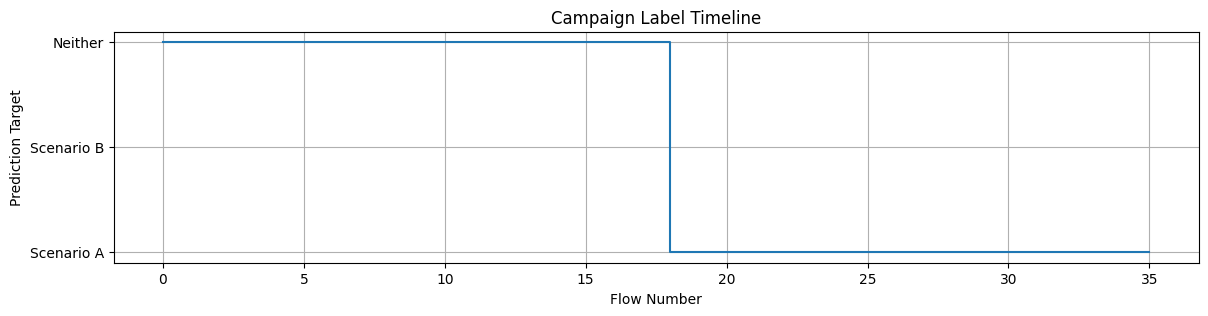

In [21]:
# ==========================================
# Cell 11 : Visualize Generated Campaigns
# ==========================================

import random
import matplotlib.pyplot as plt

scenario_map = {
    0: "Scenario A",
    1: "Scenario B",
    2: "Neither"
}

# Pick a random campaign
idx = random.randint(0, len(X_train_campaigns)-1)

campaign = X_train_campaigns[idx]
labels = Y_train_campaigns[idx]

# Ignore padded positions
valid_length = np.sum(np.linalg.norm(campaign, axis=1) > 0)

print("="*60)
print(f"Campaign Index : {idx}")
print(f"Campaign Length : {valid_length}")
print("="*60)

print("\nTimeline\n")

for i in range(valid_length):
    print(
        f"Flow {i+1:02d} ---> {scenario_map[labels[i]]}"
    )

# Plot label timeline
plt.figure(figsize=(14,3))

plt.step(
    np.arange(valid_length),
    labels[:valid_length],
    where="post"
)

plt.yticks(
    [0,1,2],
    ["Scenario A","Scenario B","Neither"]
)

plt.xlabel("Flow Number")
plt.ylabel("Prediction Target")
plt.title("Campaign Label Timeline")

plt.grid(True)

plt.show()

In [22]:
# ==========================================
# Cell 12 : Positional Encoding
# ==========================================

import tensorflow as tf
import numpy as np

class PositionalEncoding(tf.keras.layers.Layer):

    def __init__(self, max_len, d_model):
        super().__init__()

        position = np.arange(max_len)[:, np.newaxis]
        div_term = np.exp(
            np.arange(0, d_model, 2) *
            -(np.log(10000.0) / d_model)
        )

        pe = np.zeros((max_len, d_model))

        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)

        self.pe = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        length = tf.shape(x)[1]
        return x + self.pe[:, :length, :]

In [23]:
# ==========================================
# Cell 13 : Causal Transformer Block
# ==========================================

import tensorflow as tf

class TransformerBlock(tf.keras.layers.Layer):

    def __init__(
        self,
        embed_dim=64,
        num_heads=4,
        ff_dim=256,
        dropout=0.1
    ):

        super().__init__()

        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.attn = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout
        )

        self.dropout1 = tf.keras.layers.Dropout(dropout)

        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="gelu"),
            tf.keras.layers.Dropout(dropout),
            tf.keras.layers.Dense(embed_dim)
        ])

        self.dropout2 = tf.keras.layers.Dropout(dropout)

    def call(self, x, training=False):

        # ---------------------------
        # Pre-LayerNorm
        # ---------------------------
        y = self.norm1(x)

        # ---------------------------
        # Causal Self Attention
        # ---------------------------
        attn = self.attn(
            query=y,
            value=y,
            key=y,
            use_causal_mask=True,
            training=training
        )

        x = x + self.dropout1(attn, training=training)

        # ---------------------------
        # Feed Forward
        # ---------------------------
        y = self.norm2(x)

        ffn = self.ffn(y, training=training)

        x = x + self.dropout2(ffn, training=training)

        return x

In [24]:
# ==========================================
# Cell 14 : Online Causal Transformer
# ==========================================

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    Masking
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

MAX_LEN = 100
EMBED_DIM = 64

inputs = Input(
    shape=(MAX_LEN, EMBED_DIM),
    name="Campaign_Input"
)

# -------------------------------------------------
# Ignore padded vectors (all zeros)
# -------------------------------------------------

x = Masking(mask_value=0.0)(inputs)

# -------------------------------------------------
# Positional Encoding
# -------------------------------------------------

x = PositionalEncoding(MAX_LEN, EMBED_DIM)(x)

# -------------------------------------------------
# Transformer Encoder
# -------------------------------------------------

x = TransformerBlock(
    embed_dim=EMBED_DIM,
    num_heads=4,
    ff_dim=256,
    dropout=0.10
)(x)

x = TransformerBlock(
    embed_dim=EMBED_DIM,
    num_heads=4,
    ff_dim=256,
    dropout=0.10
)(x)

# -------------------------------------------------
# Final LayerNorm
# -------------------------------------------------

x = LayerNormalization()(x)

# -------------------------------------------------
# Classification Head
# -------------------------------------------------

x = Dense(
    64,
    activation="gelu"
)(x)

x = Dropout(0.20)(x)

outputs = Dense(
    3,
    activation="softmax",
    name="ScenarioPrediction"
)(x)

# -------------------------------------------------
# Build Model
# -------------------------------------------------

transformer = Model(
    inputs,
    outputs,
    name="OnlineAttackDetector"
)

# -------------------------------------------------
# Compile
# -------------------------------------------------

transformer.compile(

    optimizer=Adam(
        learning_rate=1e-4
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

transformer.summary()

Model: "OnlineAttackDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Campaign_Input (InputLayer)     │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ masking_1 (Masking)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_1           │ (None, 100, 64)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 100, 64)        │        49,984 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 100, 64)        │        49,984 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_9           │ (None, 100, 64)        │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100, 64)        │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ScenarioPrediction (Dense)      │ (None, 100, 3)         │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,451 (408.01 KB)

 Trainable params: 104,451 (408.01 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# ==========================================
# Cell 15 : Train Online Attack Detector
# ==========================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# -------------------------------------------------
# Sample Weights
# -------------------------------------------------

train_sample_weights = (
    np.linalg.norm(X_train_seq, axis=2) > 0
).astype(np.float32)

val_sample_weights = (
    np.linalg.norm(X_val_seq, axis=2) > 0
).astype(np.float32)

print("Training Sample Weights :", train_sample_weights.shape)
print("Validation Sample Weights :", val_sample_weights.shape)

# -------------------------------------------------
# Callbacks
# -------------------------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_attack_detector.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# -------------------------------------------------
# Train
# -------------------------------------------------

history = transformer.fit(

    X_train_seq,
    Y_train_seq,

    sample_weight=train_sample_weights,

    validation_data=(
        X_val_seq,
        Y_val_seq,
        val_sample_weights
    ),

    epochs=30,
    batch_size=64,
    shuffle=True,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1
)

# -------------------------------------------------
# Plot Learning Curves
# -------------------------------------------------

epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(10,5))
plt.plot(epochs, history.history["loss"], marker="o", label="Train")
plt.plot(epochs, history.history["val_loss"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, history.history["accuracy"], marker="o", label="Train")
plt.plot(epochs, history.history["val_accuracy"], marker="o", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Accuracy")
plt.grid(True)
plt.legend()
plt.show()

Training Sample Weights : (24000, 100)
Validation Sample Weights : (6000, 100)
Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.6718 - loss: 0.0328
Epoch 1: val_loss improved from None to 0.02751, saving model to best_attack_detector.keras

Epoch 1: finished saving model to best_attack_detector.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 144s 372ms/step - accuracy: 0.6703 - loss: 0.0315 - val_accuracy: 0.6601 - val_loss: 0.0275 - learning_rate: 1.0000e-04
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6665 - loss: 0.0284
Epoch 2: val_loss improved from 0.02751 to 0.02627, saving model to best_attack_detector.keras

Epoch 2: finished saving model to best_attack_detector.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 142s 374ms/step - accuracy: 0.6617 - loss: 0.0278 - val_accuracy: 0.6315 - val_loss: 0.0263 - learning_rate: 1.0000e-04
Epoch 3/30
 20/375 ━━━━━━━━━━━━━━━━━━━━ 2:05 354ms/step - accuracy: 0.6717 - loss: 0.0281

KeyboardInterrupt: 

In [28]:
# ==========================================
# Cell 16 : Generate One Test Campaign
# ==========================================

test_generator = CampaignGenerator(
    test_embedding_df,
    embedding_dim=EMBEDDING_DIM,
    max_length=100
)

# Choose Scenario
SCENARIO = "A"      # "A", "B", or "Neither"

campaign, true_labels = test_generator.generate(SCENARIO)

valid_length = np.sum(
    np.linalg.norm(campaign, axis=1) > 0
)

print(f"Campaign Length : {valid_length}")

scenario_names = {
    0:"Scenario A",
    1:"Scenario B",
    2:"Neither"
}

print("\nGround Truth Timeline\n")

for i in range(valid_length):

    print(
        f"Flow {i+1:02d} : {scenario_names[true_labels[i]]}"
    )

Campaign Length : 46

Ground Truth Timeline

Flow 01 : Neither
Flow 02 : Neither
Flow 03 : Neither
Flow 04 : Neither
Flow 05 : Neither
Flow 06 : Neither
Flow 07 : Neither
Flow 08 : Neither
Flow 09 : Neither
Flow 10 : Neither
Flow 11 : Neither
Flow 12 : Neither
Flow 13 : Neither
Flow 14 : Neither
Flow 15 : Neither
Flow 16 : Neither
Flow 17 : Neither
Flow 18 : Neither
Flow 19 : Neither
Flow 20 : Neither
Flow 21 : Neither
Flow 22 : Neither
Flow 23 : Neither
Flow 24 : Neither
Flow 25 : Neither
Flow 26 : Neither
Flow 27 : Neither
Flow 28 : Neither
Flow 29 : Scenario A
Flow 30 : Scenario A
Flow 31 : Scenario A
Flow 32 : Scenario A
Flow 33 : Scenario A
Flow 34 : Scenario A
Flow 35 : Scenario A
Flow 36 : Scenario A
Flow 37 : Scenario A
Flow 38 : Scenario A
Flow 39 : Scenario A
Flow 40 : Scenario A
Flow 41 : Scenario A
Flow 42 : Scenario A
Flow 43 : Scenario A
Flow 44 : Scenario A
Flow 45 : Scenario A
Flow 46 : Scenario A


In [29]:
# ==========================================
# Cell 17 : Online Detection
# ==========================================

import time

predictions = []
confidences = []

for t in range(1, valid_length + 1):

    current = np.zeros((1,100,64),dtype=np.float32)

    current[0,:t,:] = campaign[:t]

    probs = transformer.predict(
        current,
        verbose=0
    )[0]

    pred = np.argmax(probs[t-1])

    confidence = probs[t-1][pred]

    predictions.append(pred)
    confidences.append(confidence)

    print("="*50)
    print(f"Flow {t}")
    print(f"Prediction : {scenario_names[pred]}")
    print(f"Confidence : {confidence:.3f}")

    time.sleep(0.25)

Flow 1
Prediction : Neither
Confidence : 1.000
Flow 2
Prediction : Neither
Confidence : 1.000
Flow 3
Prediction : Neither
Confidence : 1.000
Flow 4
Prediction : Neither
Confidence : 1.000
Flow 5
Prediction : Neither
Confidence : 1.000
Flow 6
Prediction : Neither
Confidence : 1.000
Flow 7
Prediction : Neither
Confidence : 1.000
Flow 8
Prediction : Neither
Confidence : 1.000
Flow 9
Prediction : Neither
Confidence : 1.000
Flow 10
Prediction : Neither
Confidence : 1.000
Flow 11
Prediction : Neither
Confidence : 1.000
Flow 12
Prediction : Neither
Confidence : 1.000
Flow 13
Prediction : Neither
Confidence : 1.000
Flow 14
Prediction : Neither
Confidence : 1.000
Flow 15
Prediction : Neither
Confidence : 1.000
Flow 16
Prediction : Neither
Confidence : 1.000
Flow 17
Prediction : Neither
Confidence : 1.000
Flow 18
Prediction : Neither
Confidence : 1.000
Flow 19
Prediction : Neither
Confidence : 1.000
Flow 20
Prediction : Neither
Confidence : 1.000
Flow 21
Prediction : Neither
Confidence : 1.000
F

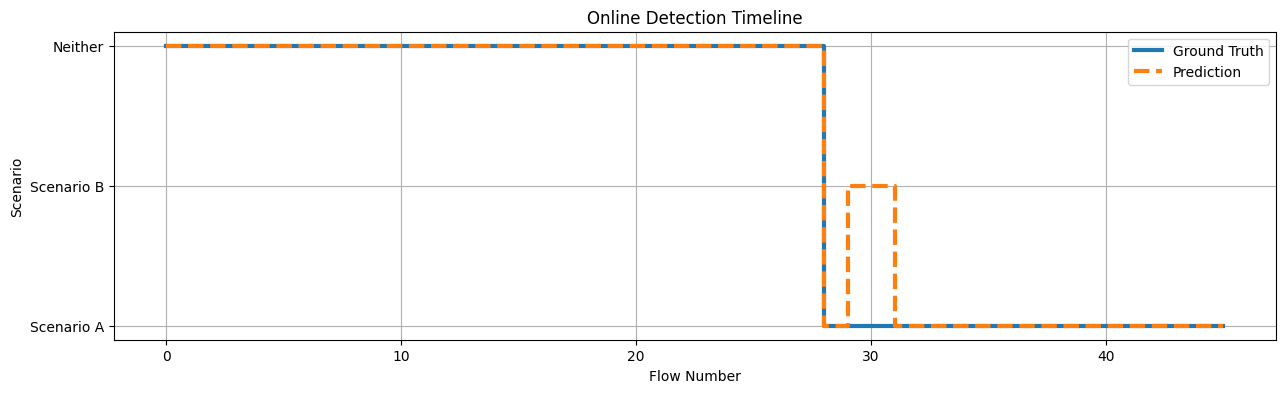

In [30]:
# ==========================================
# Cell 18 : Visualization
# ==========================================

import matplotlib.pyplot as plt

true = true_labels[:valid_length]
pred = predictions

plt.figure(figsize=(15,4))

plt.step(
    range(valid_length),
    true,
    where="post",
    label="Ground Truth",
    linewidth=3
)

plt.step(
    range(valid_length),
    pred,
    where="post",
    linestyle="--",
    label="Prediction",
    linewidth=3
)

plt.yticks(
    [0,1,2],
    ["Scenario A","Scenario B","Neither"]
)

plt.xlabel("Flow Number")
plt.ylabel("Scenario")
plt.title("Online Detection Timeline")

plt.grid(True)
plt.legend()

plt.show()

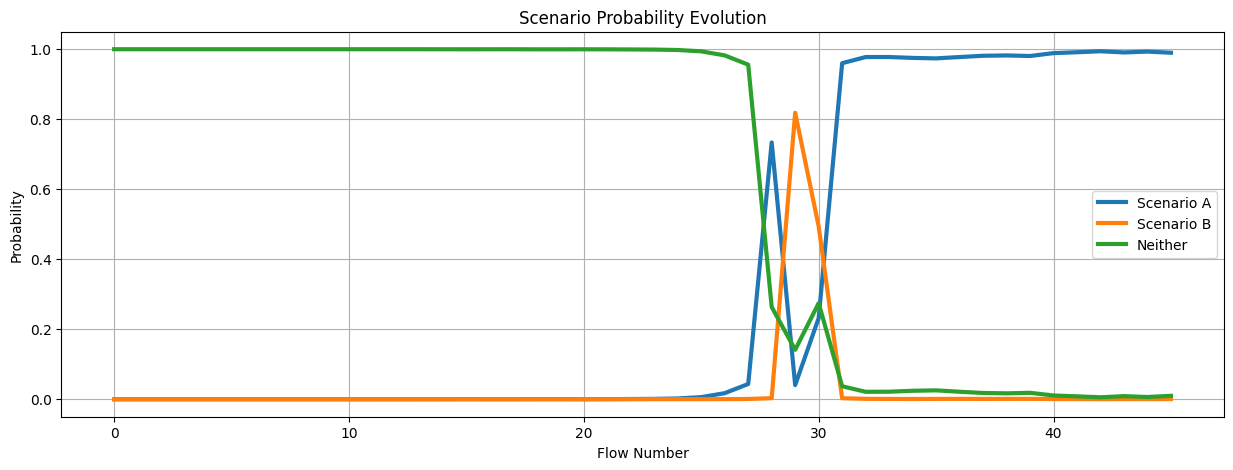

In [31]:
prob_history = []

for t in range(1, valid_length+1):

    current = np.zeros((1,100,64),dtype=np.float32)
    current[0,:t] = campaign[:t]

    probs = transformer.predict(
        current,
        verbose=0
    )[0][t-1]

    prob_history.append(probs)

prob_history = np.array(prob_history)

plt.figure(figsize=(15,5))

plt.plot(
    prob_history[:,0],
    label="Scenario A",
    linewidth=3
)

plt.plot(
    prob_history[:,1],
    label="Scenario B",
    linewidth=3
)

plt.plot(
    prob_history[:,2],
    label="Neither",
    linewidth=3
)

plt.xlabel("Flow Number")
plt.ylabel("Probability")
plt.title("Scenario Probability Evolution")

plt.grid(True)
plt.legend()

plt.show()

In [32]:
# ==========================================
# Cell 16 : Evaluate on Test Campaigns
# ==========================================

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

NUM_TEST = 300

all_true = []
all_pred = []

latencies = []

for _ in range(NUM_TEST):

    scenario = np.random.choice(["A", "B", "Neither"])

    campaign, true = test_generator.generate(scenario)

    valid_length = np.sum(np.linalg.norm(campaign, axis=1) > 0)

    detected = False

    gt_start = None
    pred_start = None

    for t in range(1, valid_length+1):

        current = np.zeros((1,100,64),dtype=np.float32)
        current[0,:t] = campaign[:t]

        probs = transformer.predict(current,verbose=0)[0]

        pred = np.argmax(probs[t-1])

        all_true.append(true[t-1])
        all_pred.append(pred)

        if gt_start is None and true[t-1] != 2:
            gt_start = t

        if pred_start is None and pred != 2:
            pred_start = t

    if gt_start is not None and pred_start is not None:
        latencies.append(pred_start-gt_start)

print(classification_report(
    all_true,
    all_pred,
    target_names=[
        "Scenario A",
        "Scenario B",
        "Neither"
    ]
))

print("\nAverage Detection Delay")

if len(latencies):
    print(np.mean(latencies),"flows")
else:
    print("No attacks detected")

KeyboardInterrupt: 

In [33]:
# ==========================================
# Cell 17 : Dashboard Metrics
# ==========================================

scenario_names = {
    0:"Scenario A",
    1:"Scenario B",
    2:"Neither"
}

campaign,true = test_generator.generate("A")

valid_length=np.sum(
    np.linalg.norm(campaign,axis=1)>0
)

history=[]

for t in range(1,valid_length+1):

    current=np.zeros((1,100,64),dtype=np.float32)
    current[0,:t]=campaign[:t]

    probs=transformer.predict(current,verbose=0)[0][t-1]

    pred=np.argmax(probs)

    history.append({

        "flow":t,

        "prediction":scenario_names[pred],

        "confidence":float(np.max(probs)),

        "scenario_a":float(probs[0]),

        "scenario_b":float(probs[1]),

        "neither":float(probs[2]),

        "ground_truth":scenario_names[true[t-1]]
    })

history[:5]

[{'flow': 1,
  'prediction': 'Neither',
  'confidence': 0.9999333024024963,
  'scenario_a': 5.3938852943247184e-05,
  'scenario_b': 1.264852107851766e-05,
  'neither': 0.9999333024024963,
  'ground_truth': 'Neither'},
 {'flow': 2,
  'prediction': 'Neither',
  'confidence': 0.9999386668205261,
  'scenario_a': 4.766044730786234e-05,
  'scenario_b': 1.3661617231264245e-05,
  'neither': 0.9999386668205261,
  'ground_truth': 'Neither'},
 {'flow': 3,
  'prediction': 'Neither',
  'confidence': 0.9999440312385559,
  'scenario_a': 4.55873305327259e-05,
  'scenario_b': 1.035551122186007e-05,
  'neither': 0.9999440312385559,
  'ground_truth': 'Neither'},
 {'flow': 4,
  'prediction': 'Neither',
  'confidence': 0.9999476075172424,
  'scenario_a': 3.6046065361006185e-05,
  'scenario_b': 1.6300033166771755e-05,
  'neither': 0.9999476075172424,
  'ground_truth': 'Neither'},
 {'flow': 5,
  'prediction': 'Neither',
  'confidence': 0.9999532103538513,
  'scenario_a': 3.011419357790146e-05,
  'scenario_b'

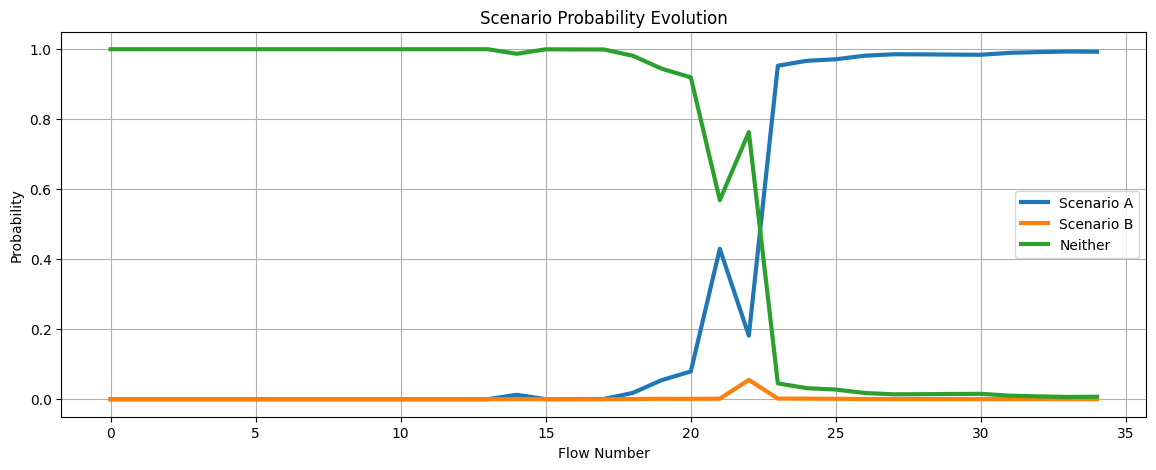

In [34]:
# ==========================================
# Cell 18 : Probability Evolution
# ==========================================

import matplotlib.pyplot as plt

sa=[]
sb=[]
ne=[]

for h in history:

    sa.append(h["scenario_a"])
    sb.append(h["scenario_b"])
    ne.append(h["neither"])

plt.figure(figsize=(14,5))

plt.plot(sa,label="Scenario A",linewidth=3)

plt.plot(sb,label="Scenario B",linewidth=3)

plt.plot(ne,label="Neither",linewidth=3)

plt.xlabel("Flow Number")

plt.ylabel("Probability")

plt.title("Scenario Probability Evolution")

plt.grid(True)

plt.legend()

plt.show()

In [35]:
# ==========================================
# Cell 19 : Save Models
# ==========================================

import joblib

embedding_classifier.save(
    "embedding_classifier.keras"
)

transformer.save(
    "attack_detector.keras"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    label_encoder,
    "label_encoder.pkl"
)

print("Saved Successfully!")

Saved Successfully!


In [36]:
# ==========================================
# Cell 20 : Complete Evaluation
# ==========================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

NUM_CAMPAIGNS = 300

all_true = []
all_pred = []

for _ in range(NUM_CAMPAIGNS):

    scenario = np.random.choice(
        ["A","B","Neither"]
    )

    campaign,true = test_generator.generate(scenario)

    valid_length = np.sum(
        np.linalg.norm(campaign,axis=1)>0
    )

    for t in range(1,valid_length+1):

        current = np.zeros((1,100,64),dtype=np.float32)
        current[0,:t] = campaign[:t]

        probs = transformer.predict(
            current,
            verbose=0
        )[0]

        pred = np.argmax(
            probs[t-1]
        )

        all_true.append(true[t-1])
        all_pred.append(pred)

print("="*60)
print("Token Accuracy")
print("="*60)

print(
    accuracy_score(
        all_true,
        all_pred
    )
)

print()

print("="*60)
print("Classification Report")
print("="*60)

print(
    classification_report(
        all_true,
        all_pred,
        target_names=[
            "Scenario A",
            "Scenario B",
            "Neither"
        ]
    )
)

cm = confusion_matrix(
    all_true,
    all_pred
)

plt.figure(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Scenario A",
        "Scenario B",
        "Neither"
    ]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")

plt.show()

KeyboardInterrupt: 

In [37]:
test_embedding_df.to_csv(
    "test_embedding_df.csv",
    index=False
)

In [ ]:
# ==========================================
# Cell 21 : Campaign Accuracy
# ==========================================

import numpy as np
from collections import defaultdict

NUM_CAMPAIGNS = 300

campaign_results = defaultdict(list)

scenario_map = {
    "A": 0,
    "B": 1,
    "Neither": 2
}

for _ in range(NUM_CAMPAIGNS):

    scenario = np.random.choice(["A", "B", "Neither"])

    campaign, true = test_generator.generate(scenario)

    valid_length = np.sum(
        np.linalg.norm(campaign, axis=1) > 0
    )

    current = np.zeros((1,100,64),dtype=np.float32)
    current[0,:valid_length] = campaign[:valid_length]

    probs = transformer.predict(
        current,
        verbose=0
    )[0]

    # Final prediction of campaign
    final_prediction = np.argmax(
        probs[valid_length-1]
    )

    gt = scenario_map[scenario]

    campaign_results[scenario].append(
        int(final_prediction == gt)
    )

print("="*60)
print("Campaign Accuracy")
print("="*60)

overall = []

for scenario in ["A","B","Neither"]:

    acc = np.mean(campaign_results[scenario])

    overall.extend(campaign_results[scenario])

    print(
        f"{scenario:10s}: {acc*100:.2f}%"
    )

print("\nOverall Campaign Accuracy")

print(f"{np.mean(overall)*100:.2f}%")

In [ ]:
# ==========================================
# Cell 22 : Detection Delay Analysis
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

NUM_CAMPAIGNS = 300

latencies = []

for _ in range(NUM_CAMPAIGNS):

    scenario = np.random.choice(["A", "B"])

    campaign, true = test_generator.generate(scenario)

    valid_length = np.sum(
        np.linalg.norm(campaign, axis=1) > 0
    )

    gt_start = None
    pred_start = None

    for t in range(1, valid_length + 1):

        current = np.zeros((1,100,64), dtype=np.float32)
        current[0,:t] = campaign[:t]

        probs = transformer.predict(
            current,
            verbose=0
        )[0]

        pred = np.argmax(probs[t-1])

        # Ground truth attack begins
        if gt_start is None and true[t-1] != 2:
            gt_start = t

        # First attack prediction
        true_attack = true[t-1]

        if pred_start is None and pred == true_attack:
            pred_start = t

    if gt_start is not None and pred_start is not None:

        latency = pred_start - gt_start

        latencies.append(latency)

# -----------------------------------------
# Results
# -----------------------------------------

print("="*60)
print("Detection Delay Statistics")
print("="*60)

print(f"Number of Attacks      : {len(latencies)}")
print(f"Average Delay          : {np.mean(latencies):.2f} flows")
print(f"Median Delay           : {np.median(latencies):.2f} flows")
print(f"Minimum Delay          : {np.min(latencies)} flows")
print(f"Maximum Delay          : {np.max(latencies)} flows")

# -----------------------------------------
# Histogram
# -----------------------------------------

plt.figure(figsize=(10,5))

plt.hist(
    latencies,
    bins=15,
    edgecolor="black"
)

plt.xlabel("Detection Delay (Flows)")
plt.ylabel("Number of Campaigns")
plt.title("Distribution of Detection Delay")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# Cell 23 : False Alarm Rate
# ==========================================

NUM_CAMPAIGNS = 300

false_alarms = 0
total_neither = 0

for _ in range(NUM_CAMPAIGNS):

    campaign, true = test_generator.generate("Neither")

    valid_length = np.sum(
        np.linalg.norm(campaign, axis=1) > 0
    )

    for t in range(1, valid_length + 1):

        current = np.zeros((1,100,64), dtype=np.float32)
        current[0,:t] = campaign[:t]

        probs = transformer.predict(
            current,
            verbose=0
        )[0]

        pred = np.argmax(probs[t-1])

        total_neither += 1

        if pred != 2:
            false_alarms += 1

false_alarm_rate = false_alarms / total_neither

print("="*60)
print("False Alarm Rate")
print("="*60)
print(f"False Alarms : {false_alarms}")
print(f"Total Benign Flows : {total_neither}")
print(f"False Alarm Rate : {false_alarm_rate*100:.2f}%")

In [ ]:
# ==========================================
# Cell 24 : Confidence Analysis
# ==========================================

confidences = []

NUM_CAMPAIGNS = 300

for _ in range(NUM_CAMPAIGNS):

    scenario = np.random.choice(["A","B"])

    campaign,true = test_generator.generate(scenario)

    valid_length = np.sum(
        np.linalg.norm(campaign,axis=1)>0
    )

    for t in range(1,valid_length+1):

        current=np.zeros((1,100,64),dtype=np.float32)
        current[0,:t]=campaign[:t]

        probs=transformer.predict(
            current,
            verbose=0
        )[0]

        pred=np.argmax(probs[t-1])

        if pred==true[t-1]:

            confidences.append(
                np.max(probs[t-1])
            )

print("="*60)
print("Confidence Analysis")
print("="*60)

print(f"Average Confidence : {np.mean(confidences):.3f}")
print(f"Minimum Confidence : {np.min(confidences):.3f}")
print(f"Maximum Confidence : {np.max(confidences):.3f}")

plt.figure(figsize=(8,4))
plt.hist(confidences,bins=20,edgecolor="black")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution")
plt.grid(True)
plt.show()

In [ ]:
# ==========================================
# Cell 25 : Inference Speed
# ==========================================

import time

campaign,true = test_generator.generate("A")

valid_length = np.sum(
    np.linalg.norm(campaign,axis=1)>0
)

times=[]

for t in range(1,valid_length+1):

    current=np.zeros((1,100,64),dtype=np.float32)
    current[0,:t]=campaign[:t]

    start=time.perf_counter()

    transformer.predict(
        current,
        verbose=0
    )

    end=time.perf_counter()

    times.append(end-start)

avg_time=np.mean(times)

print("="*60)
print("Inference Performance")
print("="*60)

print(f"Average Prediction Time : {avg_time*1000:.2f} ms")
print(f"Flows Per Second : {1/avg_time:.2f}")

In [ ]:
# ==========================================
# Cell 26 : Dashboard JSON
# ==========================================

import json

scenario_names = {
    0:"Scenario A",
    1:"Scenario B",
    2:"Neither"
}

campaign,true = test_generator.generate("A")

valid_length=np.sum(
    np.linalg.norm(campaign,axis=1)>0
)

dashboard=[]

for t in range(1,valid_length+1):

    current=np.zeros((1,100,64),dtype=np.float32)
    current[0,:t]=campaign[:t]

    probs=transformer.predict(
        current,
        verbose=0
    )[0][t-1]

    pred=np.argmax(probs)

    dashboard.append({

        "flow_number":t,

        "prediction":scenario_names[pred],

        "ground_truth":scenario_names[true[t-1]],

        "confidence":float(np.max(probs)),

        "scenario_a_probability":float(probs[0]),

        "scenario_b_probability":float(probs[1]),

        "neither_probability":float(probs[2])

    })

with open("dashboard.json","w") as f:

    json.dump(
        dashboard,
        f,
        indent=4
    )

print("dashboard.json created successfully!")

In [ ]:
# ==========================================
# Cell 27 : Generate Demo JSON
# ==========================================

import json
import numpy as np

scenario_names = {
    0: "Scenario A",
    1: "Scenario B",
    2: "Neither"
}

# ------------------------------------
# Generate one campaign
# ------------------------------------

campaign, true_labels = test_generator.generate("A")

valid_length = np.sum(
    np.linalg.norm(campaign, axis=1) > 0
)

timeline = []

flow_history = []

pred_history = []

for t in range(1, valid_length + 1):

    current = np.zeros((1,100,64),dtype=np.float32)
    current[0,:t] = campaign[:t]

    probs = transformer.predict(
        current,
        verbose=0
    )[0][t-1]

    pred = np.argmax(probs)

    event = {

        "flow_number": int(t),

        "prediction": scenario_names[pred],

        "ground_truth": scenario_names[true_labels[t-1]],

        "confidence": float(np.max(probs)),

        "probabilities": {

            "Scenario A": float(probs[0]),

            "Scenario B": float(probs[1]),

            "Neither": float(probs[2])

        }

    }

    timeline.append(event)

    flow_history.append(t)

    pred_history.append(pred)

demo = {

    "campaign_length": int(valid_length),

    "timeline": timeline,

    "summary": {

        "final_prediction":
        scenario_names[pred_history[-1]],

        "max_confidence":
        float(
            max(
                [x["confidence"] for x in timeline]
            )
        )

    }

}

with open(
    "demo_dashboard.json",
    "w"
) as f:

    json.dump(
        demo,
        f,
        indent=4
    )

print("demo_dashboard.json saved successfully.")

In [38]:
# ==========================================
# FINAL EVALUATION (FAST)
# ==========================================

import numpy as np
import time
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

NUM_CAMPAIGNS = 20      # Keep small for fast evaluation

scenario_map = {
    "A": 0,
    "B": 1,
    "Neither": 2
}

all_true = []
all_pred = []

campaign_correct = 0
campaign_total = 0

latencies = []

total_inference_time = 0
total_predictions = 0

for _ in range(NUM_CAMPAIGNS):

    scenario = np.random.choice(["A","B","Neither"])

    campaign, labels = test_generator.generate(scenario)

    valid_length = np.sum(
        np.linalg.norm(campaign,axis=1)>0
    )

    gt = scenario_map[scenario]

    # ----------------------------
    # Final Campaign Prediction
    # ----------------------------

    full = np.zeros((1,100,64),dtype=np.float32)
    full[0,:valid_length] = campaign[:valid_length]

    start = time.perf_counter()

    probs = transformer(
        full,
        training=False
    ).numpy()[0]

    total_inference_time += (
        time.perf_counter()-start
    )

    total_predictions += 1

    final_pred = np.argmax(
        probs[valid_length-1]
    )

    campaign_correct += int(final_pred==gt)
    campaign_total += 1

    # ----------------------------
    # Online Detection
    # ----------------------------

    gt_start = None
    detect = None

    for t in range(valid_length):

        if gt_start is None and labels[t]!=2:
            gt_start = t

        pred = np.argmax(probs[t])

        all_true.append(labels[t])
        all_pred.append(pred)

        if (
            detect is None
            and gt_start is not None
            and pred==labels[t]
        ):
            detect=t

    if gt_start is not None and detect is not None:
        latencies.append(
            detect-gt_start
        )

# ==========================================
# RESULTS
# ==========================================

print("="*60)
print("OVERALL RESULTS")
print("="*60)

print(f"\nToken Accuracy : {accuracy_score(all_true,all_pred)*100:.2f}%")

print(f"\nCampaign Accuracy : {(campaign_correct/campaign_total)*100:.2f}%")

print(f"\nAverage Detection Delay : {np.mean(latencies):.2f} flows")

print(f"\nAverage Inference Time : {(total_inference_time/total_predictions)*1000:.2f} ms")

print(f"Throughput : {1/(total_inference_time/total_predictions):.2f} campaigns/sec")

print("\n")

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(
    all_true,
    all_pred,
    target_names=[
        "Scenario A",
        "Scenario B",
        "Neither"
    ]
))

print("="*60)
print("CONFUSION MATRIX")
print("="*60)

print(confusion_matrix(
    all_true,
    all_pred
))

OVERALL RESULTS

Token Accuracy : 96.10%

Campaign Accuracy : 100.00%

Average Detection Delay : 1.06 flows

Average Inference Time : 73.65 ms
Throughput : 13.58 campaigns/sec


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Scenario A       0.94      0.82      0.87       114
  Scenario B       0.91      0.98      0.95       117
     Neither       0.98      0.99      0.98       487

    accuracy                           0.96       718
   macro avg       0.94      0.93      0.93       718
weighted avg       0.96      0.96      0.96       718

CONFUSION MATRIX
[[ 93  11  10]
 [  1 115   1]
 [  5   0 482]]


In [39]:
metrics = {
    "Token Accuracy": f"{accuracy_score(all_true,all_pred)*100:.2f}%",
    "Campaign Accuracy": f"{campaign_correct/campaign_total*100:.2f}%",
    "Detection Delay": f"{np.mean(latencies):.2f} flows",
    "Inference Time": f"{(total_inference_time/total_predictions)*1000:.2f} ms",
    "Throughput": f"{1/(total_inference_time/total_predictions):.2f} campaigns/sec"
}

for k, v in metrics.items():
    print(f"{k:<22}: {v}")

Token Accuracy        : 96.10%
Campaign Accuracy     : 100.00%
Detection Delay       : 1.06 flows
Inference Time        : 73.65 ms
Throughput            : 13.58 campaigns/sec
